<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [ ]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [35]:
!pip install pandas 
!pip install matplotlib

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [43]:
# Read the CSV file
survey_data = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(survey_data)

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [52]:
# Create a connection to the SQLite database
conn = sqlite3.connect("survey-data.sqlite")

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [54]:
# Reconnect to the SQLite database
conn = sqlite3.connect("survey-data.sqlite")

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   COUNT(*)
0     65437


## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [55]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,1


## Demo: Listing All Tables


To view the names of all tables in the database:


In [56]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [ ]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [13]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


In [63]:
df = pd.read_sql_query('SELECT "CompTotal" FROM main LIMIT 5', conn)
df.head()

,"""CompTotal"""
0,CompTotal


In [73]:
df.columns

Index(['"CompTotal"'], dtype='str')

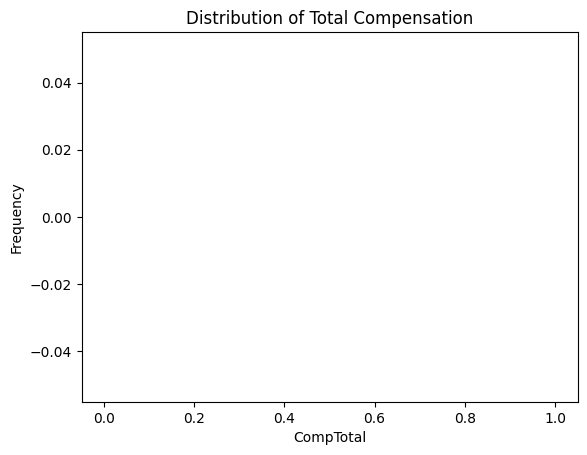

In [77]:
df = pd.read_sql_query('SELECT "CompTotal" FROM main', conn)

# clean column names
df.columns = df.columns.str.replace('"', '').str.strip()

# convert to numeric
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

# remove missing values
df = df.dropna(subset=['CompTotal'])

# remove outliers
df = df[df['CompTotal'] < 1000000]

import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['CompTotal'], bins=50)
plt.title("Distribution of Total Compensation")
plt.xlabel("CompTotal")
plt.ylabel("Frequency")
plt.show()

**Box Plots**

Plot a box plot of Age.


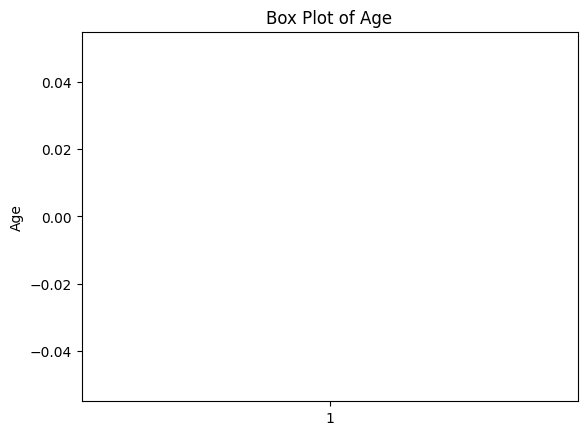

In [78]:
df_age = pd.read_sql_query('SELECT "Age" FROM main', conn)
df_age.columns = df_age.columns.str.replace('"', '').str.strip()

# convert Age to numeric if possible
df_age['Age'] = pd.to_numeric(df_age['Age'], errors='coerce')
df_age = df_age.dropna(subset=['Age'])

import matplotlib.pyplot as plt

plt.figure()
plt.boxplot(df_age['Age'])
plt.title("Box Plot of Age")
plt.ylabel("Age")
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


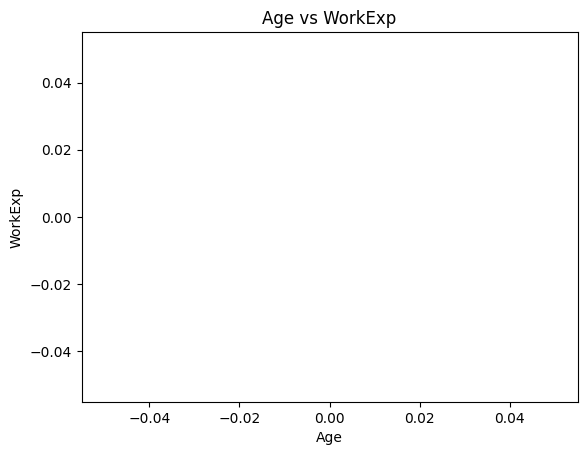

In [79]:
df_scatter = pd.read_sql_query('SELECT "Age", "WorkExp" FROM main', conn)
df_scatter.columns = df_scatter.columns.str.replace('"', '').str.strip()

df_scatter['Age'] = pd.to_numeric(df_scatter['Age'], errors='coerce')
df_scatter['WorkExp'] = pd.to_numeric(df_scatter['WorkExp'], errors='coerce')
df_scatter = df_scatter.dropna(subset=['Age', 'WorkExp'])

plt.figure()
plt.scatter(df_scatter['Age'], df_scatter['WorkExp'])
plt.title("Age vs WorkExp")
plt.xlabel("Age")
plt.ylabel("WorkExp")
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


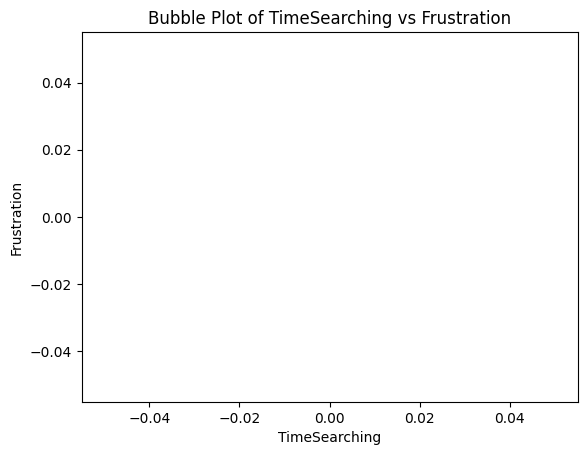

In [80]:
df_bubble = pd.read_sql_query('SELECT "TimeSearching", "Frustration", "Age" FROM main', conn)
df_bubble.columns = df_bubble.columns.str.replace('"', '').str.strip()

df_bubble['TimeSearching'] = pd.to_numeric(df_bubble['TimeSearching'], errors='coerce')
df_bubble['Frustration'] = pd.to_numeric(df_bubble['Frustration'], errors='coerce')
df_bubble['Age'] = pd.to_numeric(df_bubble['Age'], errors='coerce')
df_bubble = df_bubble.dropna(subset=['TimeSearching', 'Frustration', 'Age'])

plt.figure()
plt.scatter(
    df_bubble['TimeSearching'],
    df_bubble['Frustration'],
    s=df_bubble['Age'] * 5,
    alpha=0.5
)
plt.title("Bubble Plot of TimeSearching vs Frustration")
plt.xlabel("TimeSearching")
plt.ylabel("Frustration")
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


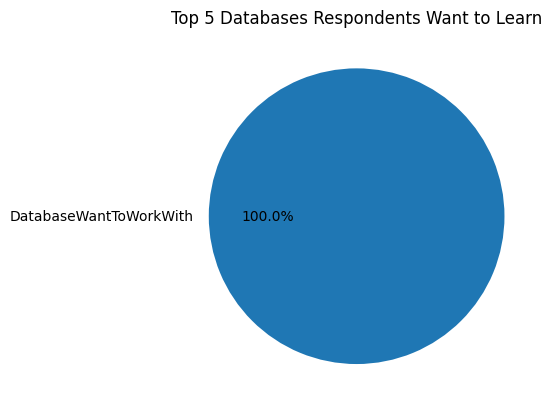

In [81]:
df_pie = pd.read_sql_query('SELECT "DatabaseWantToWorkWith" FROM main', conn)
df_pie.columns = df_pie.columns.str.replace('"', '').str.strip()

db_series = df_pie['DatabaseWantToWorkWith'].dropna().str.split(';').explode()
top5 = db_series.value_counts().head(5)

plt.figure()
plt.pie(top5, labels=top5.index, autopct='%1.1f%%')
plt.title("Top 5 Databases Respondents Want to Learn")
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


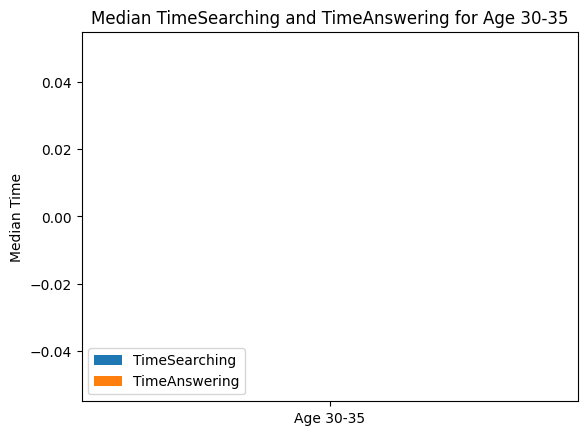

In [82]:
df_stack = pd.read_sql_query('SELECT "Age", "TimeSearching", "TimeAnswering" FROM main', conn)
df_stack.columns = df_stack.columns.str.replace('"', '').str.strip()

df_stack['Age'] = pd.to_numeric(df_stack['Age'], errors='coerce')
df_stack['TimeSearching'] = pd.to_numeric(df_stack['TimeSearching'], errors='coerce')
df_stack['TimeAnswering'] = pd.to_numeric(df_stack['TimeAnswering'], errors='coerce')

df_stack = df_stack.dropna(subset=['Age', 'TimeSearching', 'TimeAnswering'])
df_stack = df_stack[(df_stack['Age'] >= 30) & (df_stack['Age'] <= 35)]

median_searching = df_stack['TimeSearching'].median()
median_answering = df_stack['TimeAnswering'].median()

plt.figure()
plt.bar(['Age 30-35'], [median_searching], label='TimeSearching')
plt.bar(['Age 30-35'], [median_answering], bottom=[median_searching], label='TimeAnswering')
plt.title("Median TimeSearching and TimeAnswering for Age 30-35")
plt.ylabel("Median Time")
plt.legend()
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


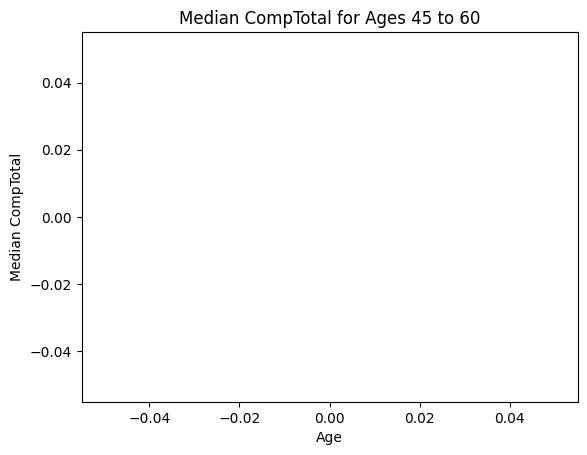

In [83]:
df_line = pd.read_sql_query('SELECT "Age", "CompTotal" FROM main', conn)
df_line.columns = df_line.columns.str.replace('"', '').str.strip()

df_line['Age'] = pd.to_numeric(df_line['Age'], errors='coerce')
df_line['CompTotal'] = pd.to_numeric(df_line['CompTotal'], errors='coerce')

df_line = df_line.dropna(subset=['Age', 'CompTotal'])
df_line = df_line[(df_line['Age'] >= 45) & (df_line['Age'] <= 60)]

median_comp = df_line.groupby('Age')['CompTotal'].median()

plt.figure()
plt.plot(median_comp.index, median_comp.values, marker='o')
plt.title("Median CompTotal for Ages 45 to 60")
plt.xlabel("Age")
plt.ylabel("Median CompTotal")
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


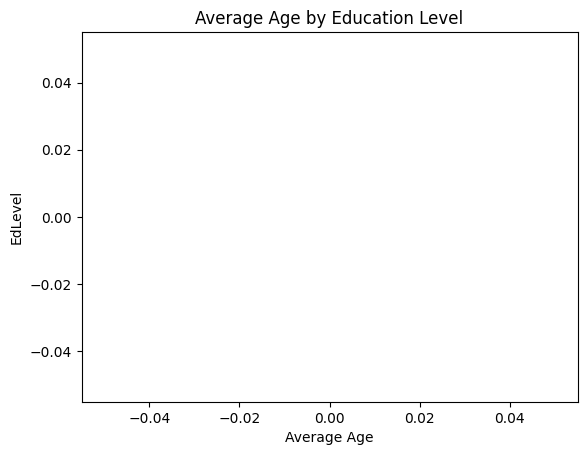

In [84]:
df_bar = pd.read_sql_query('SELECT "Age", "EdLevel" FROM main', conn)
df_bar.columns = df_bar.columns.str.replace('"', '').str.strip()

df_bar['Age'] = pd.to_numeric(df_bar['Age'], errors='coerce')
df_bar = df_bar.dropna(subset=['Age', 'EdLevel'])

avg_age = df_bar.groupby('EdLevel')['Age'].mean().sort_values()

plt.figure()
plt.barh(avg_age.index, avg_age.values)
plt.title("Average Age by Education Level")
plt.xlabel("Average Age")
plt.ylabel("EdLevel")
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
